# E-Commerce Customer Intelligence & Sales Analytics
## Notebook 06 - RFM & Customer Segmentation

**IBM SkillsBuild Data Analytics with AI Internship 2026**

---

### Scope
This notebook loads the `customer_summary.csv` pre-calculated in Notebook 03 and performs:
1. **RFM Analysis**: Recency, Frequency, and Monetary scoring.
2. **K-Means Clustering**: Unsupervised machine learning to discover customer segments based on RFM metrics.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configuration
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

OUTPUTS_DIR = '../outputs/'
FIGURES_DIR = '../outputs/figures/'

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Load Data

In [2]:
df_customers = pd.read_csv(OUTPUTS_DIR + 'customer_summary.csv')
df_customers['first_purchase_date'] = pd.to_datetime(df_customers['first_purchase_date'])
df_customers['last_purchase_date'] = pd.to_datetime(df_customers['last_purchase_date'])

# Filter out customers with zero or negative revenue
df_customers = df_customers[df_customers['total_revenue'] > 0]
print(f"Loaded {len(df_customers):,} valid customers for analysis.")
df_customers.head()


Loaded 5,851 valid customers for analysis.


,customer_id,first_purchase_date,last_purchase_date,total_orders,total_units,total_revenue,unique_products,average_order_value,customer_lifetime_days
0,"12,346.0000",2010-03-02 13:08:00,2011-01-18 10:01:00,3,74238,"77,347.0100",24,"25,782.3367",321
1,"12,347.0000",2010-10-31 14:20:00,2011-12-07 15:52:00,8,3286,"5,633.3200",126,704.1650,402
2,"12,348.0000",2010-09-27 14:59:00,2011-09-25 13:13:00,5,2704,"1,658.4000",24,331.6800,362
3,"12,349.0000",2010-04-29 13:20:00,2011-11-21 09:51:00,3,1621,"3,678.6900",137,"1,226.2300",570
4,"12,350.0000",2011-02-02 16:01:00,2011-02-02 16:01:00,1,196,294.4000,16,294.4000,0


## 2. RFM Calculation
- **Recency**: Days since last purchase (relative to snapshot date: 2011-12-10).
- **Frequency**: Total number of orders.
- **Monetary**: Total revenue.


In [3]:
snapshot_date = pd.to_datetime('2011-12-10')
df_customers['Recency'] = (snapshot_date - df_customers['last_purchase_date']).dt.days
df_customers['Frequency'] = df_customers['total_orders']
df_customers['Monetary'] = df_customers['total_revenue']

rfm = df_customers[['customer_id', 'Recency', 'Frequency', 'Monetary']].copy()
rfm.set_index('customer_id', inplace=True)
rfm.describe()


,Recency,Frequency,Monetary
count,"5,851.0000","5,851.0000","5,851.0000"
mean,199.7291,6.2512,"2,936.3360"
std,208.5410,12.7462,"14,395.1531"
min,0.0000,1.0000,2.9500
25%,25.0000,1.0000,341.2650
50%,95.0000,3.0000,868.4800
75%,379.0000,7.0000,"2,254.1150"
max,738.0000,373.0000,"595,861.9300"


In [4]:
# Scoring (1-5, where 5 is best)
# For Recency: lower is better (5 = most recent)
r_labels = range(5, 0, -1) 
r_quartiles = pd.qcut(rfm['Recency'], q=5, labels=r_labels)

# For Frequency and Monetary: higher is better (5 = most)
# Frequency is highly skewed, so we might use rank before qcut, or custom bins
f_labels = range(1, 6)
f_quartiles = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=f_labels)

m_labels = range(1, 6)
m_quartiles = pd.qcut(rfm['Monetary'], q=5, labels=m_labels)

rfm = rfm.assign(R=r_quartiles.values, F=f_quartiles.values, M=m_quartiles.values)
rfm['RFM_Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)

rfm.head()


,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score
customer_id,,,,,,,,
"12,346.0000",325,3,"77,347.0100",2,3,5,235,10
"12,347.0000",2,8,"5,633.3200",5,4,5,545,14
"12,348.0000",75,5,"1,658.4000",3,4,4,344,11
"12,349.0000",18,3,"3,678.6900",5,3,5,535,13
"12,350.0000",310,1,294.4000,2,1,2,212,5


## 3. K-Means Clustering

In [5]:
# Data Transformation for K-Means (Log transform to handle skewness)
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(lambda x: np.log(x + 1))

# Scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Fit K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

rfm['Cluster'] = kmeans.labels_
rfm.head()


,Recency,Frequency,Monetary,R,F,M,RFM_Segment,RFM_Score,Cluster
customer_id,,,,,,,,,
"12,346.0000",325,3,"77,347.0100",2,3,5,235,10,1
"12,347.0000",2,8,"5,633.3200",5,4,5,545,14,2
"12,348.0000",75,5,"1,658.4000",3,4,4,344,11,1
"12,349.0000",18,3,"3,678.6900",5,3,5,535,13,0
"12,350.0000",310,1,294.4000,2,1,2,212,5,3


In [6]:
# Analyze clusters
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

display(cluster_summary)


Recency Frequency    Monetary      
            mean      mean        mean count
Cluster                                     
0        27.4000    3.0000    841.5000  1229
1       221.9000    5.2000  2,012.4000  1479
2        26.6000   19.4000 10,829.9000  1157
3       390.7000    1.4000    322.1000  1986

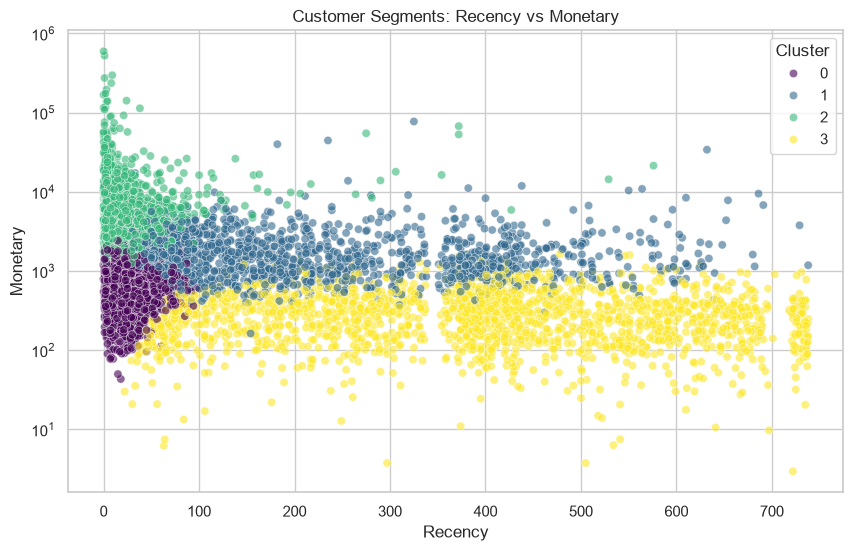

In [7]:
# Visualize Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette='viridis', alpha=0.6)
plt.title('Customer Segments: Recency vs Monetary')
plt.yscale('log')
plt.savefig(FIGURES_DIR + '52_kmeans_clusters.png', bbox_inches='tight')
plt.show()


In [8]:
# Save final segment assignments
rfm.to_csv(OUTPUTS_DIR + 'customer_segments.csv')
print("Saved customer_segments.csv")


Saved customer_segments.csv
